# Covasim Graph Generation & Distance Comparison

This notebook:
1. Generates **N=5 contact networks** from covasim simulations (varying random seed)
2. Computes node embeddings with EDRep
3. Measures all pairwise distances with three metrics:
   - **EmbDistance** (unmatched spectral distance)
   - **w2_distance** (Wasserstein on full Gram matrix)
   - **w2_distance_classes** (Wasserstein per sex partition: female / male)
4. Displays the three N×N distance matrices as heatmaps

## 1. Setup

In [1]:
# Uncomment to install covasim if not already available
# !pip install covasim

In [2]:
import sys
import os

# Add project root to path so we can import functions.py and EDRep_main
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import networkx as nx
import ot
import matplotlib.pyplot as plt
import seaborn as sns
import covasim as cv

from EDRep_main.EDRep import NodeEmbedding
from functions import w2_distance_classes

Covasim 3.1.7 (2026-02-18) — © 2020-2026 by IDM

## 2. Graph Generation

In [3]:
def covasim_graph(pop_size=200, seed=0):
    """Run a covasim simulation and return the contact network as a NetworkX graph."""
    sim = cv.Sim(pop_size=pop_size, rand_seed=seed, verbose=0)
    sim.run()

    n = len(sim.people)  # covasim 3.x: use len() instead of .n
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Add edges from all available contact layers
    for layer in sim.people.contacts.values():
        edges = zip(layer['p1'].tolist(), layer['p2'].tolist())
        G.add_edges_from(edges)

    # Attach node attributes
    for i in range(n):
        G.nodes[i]['sex'] = int(sim.people.sex[i])   # 0 = female, 1 = male
        G.nodes[i]['age'] = float(sim.people.age[i])

    return G

In [4]:
N = 5
POP_SIZE = 200

graphs = []
for seed in range(N):
    G = covasim_graph(pop_size=POP_SIZE, seed=seed)
    graphs.append(G)
    n_female = sum(1 for _, d in G.nodes(data=True) if d['sex'] == 0)
    n_male   = sum(1 for _, d in G.nodes(data=True) if d['sex'] == 1)
    print(f"Graph {seed}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges | "
          f"female={n_female}, male={n_male}")

Graph 0: 200 nodes, 1941 edges | female=94, male=106

Graph 1: 200 nodes, 1893 edges | female=97, male=103

Graph 2: 200 nodes, 1833 edges | female=108, male=92

Graph 3: 200 nodes, 1976 edges | female=103, male=97

Graph 4: 200 nodes, 1896 edges | female=90, male=110

## 3. Node Embeddings (EDRep)

In [5]:
def get_embedding(G, dim=16, seed=42):
    """Compute EDRep node embedding for graph G."""
    A = nx.to_scipy_sparse_array(G, format='csr')
    np.random.seed(seed)
    emb = NodeEmbedding(A, dim=dim, k=1, verbose=False)
    return emb.X

In [6]:
DIM = 16

embeddings = []
for i, G in enumerate(graphs):
    X = get_embedding(G, dim=DIM)
    embeddings.append(X)
    print(f"Graph {i}: embedding shape {X.shape}")

Graph 0: embedding shape (200, 16)

Graph 1: embedding shape (200, 16)

Graph 2: embedding shape (200, 16)

Graph 3: embedding shape (200, 16)

Graph 4: embedding shape (200, 16)

## 4. Distance Functions

In [7]:
def EmbDistance(X, Y, distance_type='unmatched'):
    """Embedding-based graph distance (spectral / unmatched or matched Frobenius)."""
    n1, d1 = X.shape
    n2, d2 = Y.shape

    if d1 != d2:
        raise ValueError('The embedding matrices have different dimensions')
    if distance_type not in ['unmatched', 'matched']:
        raise ValueError('distance_type must be unmatched or matched')
    if distance_type == 'matched' and n1 != n2:
        raise ValueError('Matched distance requires same number of nodes')

    if distance_type == 'matched':
        Mxx = X.T @ X
        Mxy = X.T @ Y
        Myy = Y.T @ Y
        return np.sqrt(np.abs(
            np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2
        ))
    else:
        lam1 = np.linalg.eigvalsh(X.T @ X) / n1
        lam2 = np.linalg.eigvalsh(Y.T @ Y) / n2
        return np.linalg.norm(lam1 - lam2)


def w2_distance(emb_1, emb_2):
    """Wasserstein-2 distance between two embeddings via flattened Gram matrices."""
    vals_1 = (emb_1 @ emb_1.T).flatten()
    vals_2 = (emb_2 @ emb_2.T).flatten()
    return ot.wasserstein_1d(vals_1, vals_2, p=2)**(1/2)


def sex_partition(G, X):
    """Split embedding rows by sex attribute (0=female, 1=male)."""
    sexes = np.array([G.nodes[i]['sex'] for i in range(G.number_of_nodes())])
    return [X[sexes == 0], X[sexes == 1]]

## 5. Pairwise Distance Matrices

In [8]:
D_emb = np.zeros((N, N))
D_w2  = np.zeros((N, N))
D_cls = np.zeros((N, N))

for i in range(N):
    for j in range(i + 1, N):
        D_emb[i, j] = EmbDistance(embeddings[i], embeddings[j])
        D_w2 [i, j] = w2_distance(embeddings[i], embeddings[j])
        D_cls[i, j] = w2_distance_classes(
            sex_partition(graphs[i], embeddings[i]),
            sex_partition(graphs[j], embeddings[j])
        )[0]

        # Symmetrise
        D_emb[j, i] = D_emb[i, j]
        D_w2 [j, i] = D_w2 [i, j]
        D_cls[j, i] = D_cls[i, j]

labels = [f"Graph {i}" for i in range(N)]
print("EmbDistance matrix:")
print(D_emb)
print("\nw2_distance matrix:")
print(D_w2)
print("\nw2_distance_classes matrix:")
print(D_cls)

EmbDistance matrix:

[[0.         0.01320281 0.0103946  0.01103303 0.01019059]
 [0.01320281 0.         0.0087183  0.01128881 0.00973211]
 [0.0103946  0.0087183  0.         0.01161005 0.00745945]
 [0.01103303 0.01128881 0.01161005 0.         0.00966565]
 [0.01019059 0.00973211 0.00745945 0.00966565 0.        ]]


w2_distance matrix:

[[0.         0.00281085 0.00291044 0.0037681  0.00320879]
 [0.00281085 0.         0.00241895 0.00271815 0.00214942]
 [0.00291044 0.00241895 0.         0.00223121 0.00187671]
 [0.0037681  0.00271815 0.00223121 0.         0.00216516]
 [0.00320879 0.00214942 0.00187671 0.00216516 0.        ]]


w2_distance_classes matrix:

[[0.         0.01099056 0.01212991 0.011921   0.01335523]
 [0.01099056 0.         0.00890394 0.01096965 0.00931778]
 [0.01212991 0.00890394 0.         0.00965596 0.01034332]
 [0.011921   0.01096965 0.00965596 0.         0.01202985]
 [0.01335523 0.00931778 0.01034332 0.01202985 0.        ]]

## 6. Visualization

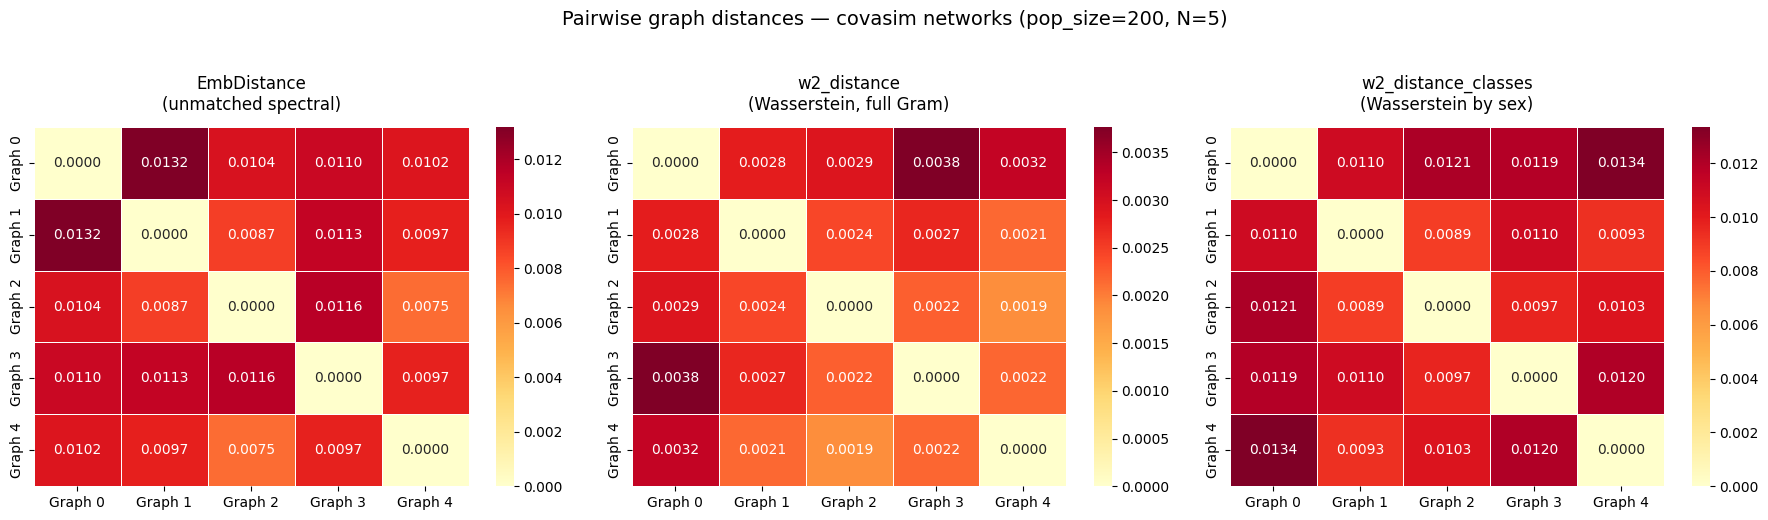

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [
    (D_emb, "EmbDistance\n(unmatched spectral)"),
    (D_w2,  "w2_distance\n(Wasserstein, full Gram)"),
    (D_cls, "w2_distance_classes\n(Wasserstein by sex)"),
]

for ax, (mat, title) in zip(axes, matrices):
    sns.heatmap(
        mat,
        ax=ax,
        annot=True,
        fmt=".4f",
        cmap="YlOrRd",
        linewidths=0.5,
        xticklabels=labels,
        yticklabels=labels,
    )
    ax.set_title(title, pad=12)

plt.suptitle(
    f"Pairwise graph distances — covasim networks (pop_size={POP_SIZE}, N={N})",
    fontsize=14, y=1.03
)
plt.tight_layout()
plt.show()